In [58]:
pip install roboflow

In [59]:
from google.colab import files

uploaded = files.upload()

Saving Test.jpeg to Test (2).jpeg


In [67]:
import cv2
import numpy as np

def is_blurry(img, threshold=100):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    score = cv2.Laplacian(gray, cv2.CV_64F).var()
    return score < threshold, score


def brightness_level(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = np.mean(gray)

    if brightness < 60:
        level = "Dark"
    elif brightness < 100:
        level = "Low Light"
    elif brightness < 180:
        level = "Normal"
    else:
        level = "Too Bright"

    return level, brightness


def enhance_image(img):
    # brightness + contrast fix
    img = cv2.convertScaleAbs(img, alpha=1.3, beta=25)

    # CLAHE (fix lighting in fridge)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    l = clahe.apply(l)

    img = cv2.cvtColor(cv2.merge((l,a,b)), cv2.COLOR_LAB2BGR)

    # sharpen
    kernel = np.array([[0,-1,0],
                       [-1,5,-1],
                       [0,-1,0]])
    img = cv2.filter2D(img, -1, kernel)

    return img


def smart_fridge_ai(image_path):
    img = cv2.imread(image_path)

    if img is None:
        return "Image not found (check filename)"

    # check brightness
    level, bright = brightness_level(img)

    # check blur
    blur, blur_score = is_blurry(img)

    print("Brightness:", level, "| Score:", bright)
    print("Blur score:", blur_score)

    # auto enhance if needed
    if level in ["Dark", "Low Light"] or blur:
        print("⚙️ Enhancing image...")
        img = enhance_image(img)
        cv2.imwrite("enhanced.jpg", img)
        return "Enhanced image saved as enhanced.jpg"

    return "Image is already good quality"


# RUN
result = smart_fridge_ai("Test.jpeg")
print(result)

Brightness: Normal | Score: 139.67417112986246
Blur score: 75.314111960033
⚙️ Enhancing image...
Enhanced image saved as enhanced.jpg


In [61]:
import os

print(os.listdir())

['.config', 'Test.jpeg', 'inventory.json', 'Test (2).jpeg', 'enhanced.jpg', 'Test (1).jpeg', 'sample_data']


In [62]:
from roboflow import Roboflow

rf = Roboflow(api_key="FD5ojAsUYbtrWJjZ88rM")
project = rf.workspace().project("egg-zauue")
model = project.version(1).model

# run prediction on image
result = model.predict(
    'Test.jpeg',
    confidence=40,
    overlap=30
).json()


print(result)

loading Roboflow workspace...
loading Roboflow project...
{'predictions': [{'x': 1724, 'y': 727, 'width': 326, 'height': 432, 'confidence': 0.9168766140937805, 'class': 'Egg', 'class_id': 0, 'detection_id': '9cc8aa3f-3d21-4372-ad1c-6fd804cc9334', 'image_path': 'Test.jpeg', 'prediction_type': 'ObjectDetectionModel'}, {'x': 1531, 'y': 510, 'width': 316, 'height': 304, 'confidence': 0.8892955780029297, 'class': 'Egg', 'class_id': 0, 'detection_id': '2fcd5eb3-3d33-495d-b13c-66cbbe105788', 'image_path': 'Test.jpeg', 'prediction_type': 'ObjectDetectionModel'}, {'x': 1356, 'y': 816, 'width': 384, 'height': 417, 'confidence': 0.8698388338088989, 'class': 'Egg', 'class_id': 0, 'detection_id': '87ef2cb5-589a-4dc7-a70c-fc8e248556f1', 'image_path': 'Test.jpeg', 'prediction_type': 'ObjectDetectionModel'}, {'x': 1192, 'y': 590, 'width': 323, 'height': 369, 'confidence': 0.7954394817352295, 'class': 'Egg', 'class_id': 0, 'detection_id': '0d85144a-1446-4ec3-b1a6-511f8e1c6816', 'image_path': 'Test.jpeg

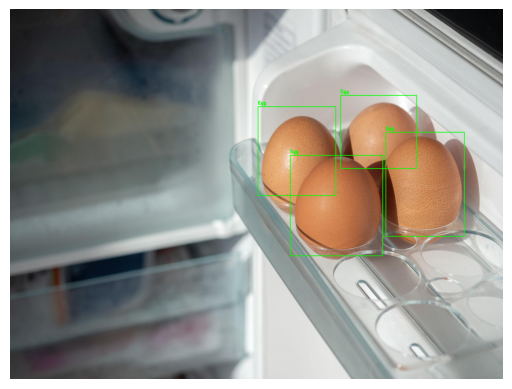

In [63]:
import cv2
from roboflow import Roboflow
from matplotlib import pyplot as plt

# load image
image_path = "Test.jpeg"
image = cv2.imread(image_path)

# run prediction
predictions = model.predict(image_path, confidence=40, overlap=30).json()

# draw boxes
for p in predictions["predictions"]:
    x = int(p["x"])
    y = int(p["y"])
    w = int(p["width"])
    h = int(p["height"])
    label = p["class"]

    x1 = int(x - w/2)
    y1 = int(y - h/2)
    x2 = int(x + w/2)
    y2 = int(y + h/2)

    cv2.rectangle(image, (x1, y1), (x2, y2), (0,255,0), 2)
    cv2.putText(image, label, (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

# show image
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [64]:
egg_count = len(result["predictions"])

if egg_count < 4:
    print("⚠ LOW STOCK - Please restock eggs")
else:
    print("Stock OK")

Stock OK


In [65]:
import json
from datetime import datetime

def update_inventory(item, count):
    try:
        with open("inventory.json", "r") as f:
            data = json.load(f)
    except:
        data = {}

    data[item] = {
        "count": count,
        "last_updated": str(datetime.now())
    }

    with open("inventory.json", "w") as f:
        json.dump(data, f, indent=4)

# example
update_inventory("egg", 12)

In [69]:
from datetime import datetime, timedelta

def add_item_with_expiry(item, days_valid):
    expiry_date = datetime.now() + timedelta(days=days_valid)

    return {
        "Item": item,
        "Expiry_Date": expiry_date,
        "Days_Left": days_valid
    }


def check_freshness(item_data):
    days_left = item_data["Days_Left"]

    if days_left > 10:
        status = "🟢 Fresh"
    elif 3 < days_left <= 10:
        status = "🟡 Expiry Soon"
    else:
        status = "🔴 Expired / Use Immediately"

    return status


# Create egg data
egg = add_item_with_expiry("Egg", 21)

# Check status
status = check_freshness(egg)

print("Item:", egg["Item"])
print("Expiry Date:", egg["Expiry_Date"].strftime("%Y-%m-%d"))
print("Status:", status)

Item: Egg
Expiry Date: 2026-05-13
Status: 🟢 Fresh
